[二叉搜索树](./advanced_algorithm/binary_search_tree.md)  


二叉搜索树（binary search tree）满足以下条件。
1. 对于根节点，左子树中所有节点的值 < 根节点的值 < 右子树中所有节点的值。
2. 任意节点的左、右子树也是二叉搜索树，即同样满足条件 1. 。

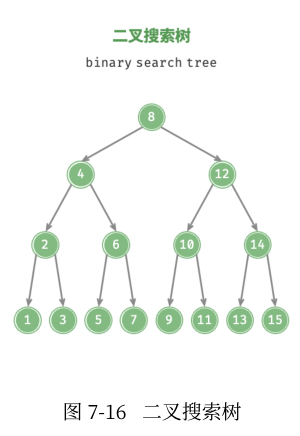

### 98. 验证二叉搜索树
> 给定一个二叉树的根节点 root ，判断其是否是一个有效的二叉搜索树。

- 思路1：在前序遍历迭代模版上改点代码，可以做到遇到不平衡的二叉树提前结束遍历。这是最优的
- 思路2：除此之外，还可以判断这棵树的中序遍历是否是个严格递增的数组。
- 思路3：也可以使用后序遍历迭代模版实现，缺点是，不能提前结束

In [1]:
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

def isValidBST(root) -> bool:
        if root is None: return True

        stack = [(root, float("-inf"), float("inf"))]
        while len(stack) > 0:
            node , low,up = stack.pop()
            if node.right is not None:
                if node.right.val <= node.val or node.right.val >= up:
                    return False
                stack.append((node.right, node.val, up))
            if node.left is not None:
                if node.left.val >= node.val or node.left.val <= low:
                    return False
                stack.append((node.left, low, node.val))

        return True

### 701. 二叉搜索树中的插入操作
>给定二叉搜索树（BST）的根节点和要插入树中的值，将值插入二叉搜索树。 返回插入后二叉搜索树的根节点。 保证原始二叉搜索树中不存在新值。

思路：插入到叶子结点即可，这样就不必麻烦的维持二叉树的平衡了

In [2]:
def insertIntoBST(root,val):
    if not root: return TreeNode(val)
    
    if val > root.val:
        root.right = insertIntoBST(root.right, val)
    elif val < root.val:
        root.left = insertIntoBST(root.left, val)
    return root

### 450. 删除二叉搜索树中的节点
>给定一个二叉搜索树的根节点 root 和一个值 key，删除二叉搜索树中的  key  对应的节点，并保证二叉搜索树的性质不变。返回二叉搜索树（有可能被更新）的根节点的引用。

思路：尝试找到节点，如果找到删除它。

In [ ]:
def deleteNode(root, key):
    if not root: return None
    
    # 尝试找到这个节点
    dummy = TreeNode(left=root)
    parent, node = dummy, node
    isleft = True
    while node and node != key:
        parent = node
        isleft = key< node.val
        node = node.left if isleft else node.right
    # if found
    if node:
        if not node.right:
            if isleft:
                parent.left = node.left
            else:
                parent.right = node.left
        elif not node.left:
            if isleft:
                parent.left = node.right
            else:
                parent.right = node.right
        else:
            # 既有左值又有右值,比如删除第一层的根节点，那么就是去左边找最大值放到替代这个位置
            p,n = node,node.left
            while n.right:
                p,n = n, n.right
            if p != node:
                p.right = n.left
            else:
                p.left = n.left
            n.left, n.right = node.left, node.right
            if isleft:
                parent.left = n
            else:
                parent.right = n
    return dummy.left 
            

### 110. 平衡二叉树
>给定一个二叉树，判断它是否是高度平衡的二叉树。

- 思路1：左边平衡 & 右边平衡 & 高度差小于2。分治法。递归实现  
- 思路2：后序遍历迭代模版


In [4]:
def isBalanced(root):
    def depth(root):
        if not root: return True,0
    
        l_balanced, l_depth = depth(root.left)
        r_balanced, r_depth = depth(root.right)
        
        return l_balanced and r_balanced and abs(l_depth-r_depth)<2, 1+max(l_depth, r_depth)
    out, _ = depth(root)
    return out

### valid-bfs-of-bst
>给定一个整数数组，求问此数组是不是一个 BST 的 BFS 顺序。

此题是面试真题，但是没有在 leetcode 上找到原题。由于做法比较有趣也很有 BST 的特点，补充在这供参考。

interval: 区间


In [6]:
import collections
def bst_bfs(nums):
    N = len(nums)
    interval = collections.deque([(float('-inf'),nums[0]), (nums[0], float('inf'))])
    for i in range(1, N):
        while interval:
            lower , upper = interval.popleft()
            if lower < nums[i] < upper:
                interval.append((lower, nums[i]))
                interval.append((nums[i], upper))
                break  # 停止在第一个合法区间处更新并退出循环。
        if not interval:
            return False
    return True

nums = [10, 8, 11, 1, 9, 0, 5, 3, 6, 4, 12]
print(bst_bfs(nums))
nums = [10, 8, 11, 1, 9, 0, 5, 3, 6, 4, 7]
print(bst_bfs(nums))

False
True
